In [50]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from datasets import load_dataset
from sklearn.model_selection import train_test_split
# 1. Clear Ghost Memory: 
# Previous crashes leave "zombie" graphs in the GPU memory. This flushes them out.
tf.keras.backend.clear_session()

# 2. Enable Memory Growth:
# Prevents TensorFlow from blindly allocating 100% of the VRAM immediately.
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        for gpu in physical_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# 3. Enable Mixed Precision (The Silver Bullet):
# This forces the GPU to use float16 for calculations but keeps variables in float32. 
# It literally cuts your VRAM requirement in half without hurting accuracy.
tf.keras.mixed_precision.set_global_policy('mixed_float16')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = "3"

BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-3
STEPS = len(train_cover) // BATCH_SIZE + 1

# Load Dataset
dataset = load_dataset("zh-plus/tiny-imagenet")
train_cover, train_secret = train_test_split(dataset['train']['image'][:15000], train_size=0.5, shuffle=True)
test_cover, test_secret = train_test_split(dataset['valid']['image'][:1000], train_size=0.5, shuffle=True)
holdout_cover, holdout_secret = train_test_split(
    dataset['train']['image'][15000:16000], # Taking the next 1000 images
    train_size=0.5, 
    shuffle=True
)
del dataset # Free memory

# Generator to lazily load images and prevent RAM saturation
def make_generator(cover_list, secret_list):
    def generator():
        for c, s in zip(cover_list, secret_list):
            yield (np.array(c.convert('RGB'), dtype=np.float32), 
                   np.array(s.convert('RGB'), dtype=np.float32))
    return generator

# Build optimized tf.data pipelines
output_sig = (tf.TensorSpec(shape=(64, 64, 3), dtype=tf.float32), 
              tf.TensorSpec(shape=(64, 64, 3), dtype=tf.float32))

train_dataset = tf.data.Dataset.from_generator(
    make_generator(train_cover, train_secret), output_signature=output_sig
).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_generator(
    make_generator(test_cover, test_secret), output_signature=output_sig
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [51]:
@tf.function
def conv2d(input, filters, biases, strides=1):
    x = tf.nn.conv2d(input, filters, strides=[1, strides, strides, 1], padding='SAME')
    x = tf.nn.bias_add(x, biases)
    return tf.nn.relu(x)

@tf.function
def conv2d_sigmoid(input, filters, biases, strides=1):
    x = tf.nn.conv2d(input, filters, strides=[1, strides, strides, 1], padding='SAME')
    x = tf.nn.bias_add(x, biases)
    return tf.nn.sigmoid(x) # Forces output to be between 0.0 and 1.0

initializer = tf.initializers.glorot_normal(12541)

In [52]:
WEIGHTS_PREP_NETWORK = {
    'conv3x3_1': tf.Variable(initializer([3, 3, 3, 50])),
    'conv3x3_2': tf.Variable(initializer([3, 3, 50, 50])),
    'conv3x3_3': tf.Variable(initializer([3, 3, 50, 50])),
    'conv3x3_4': tf.Variable(initializer([3, 3, 50, 50])),

    'conv4x4_1': tf.Variable(initializer([4, 4, 3, 50])),
    'conv4x4_2': tf.Variable(initializer([4, 4, 50, 50])),
    'conv4x4_3': tf.Variable(initializer([4, 4, 50, 50])),
    'conv4x4_4': tf.Variable(initializer([4, 4, 50, 50])),

    'conv5x5_1': tf.Variable(initializer([5, 5, 3, 50])),
    'conv5x5_2': tf.Variable(initializer([5, 5, 50, 50])),
    'conv5x5_3': tf.Variable(initializer([5, 5, 50, 50])),
    'conv5x5_4': tf.Variable(initializer([5, 5, 50, 50])),

    'conv3x3_5': tf.Variable(initializer([3, 3, 150, 50])),
    'conv4x4_5': tf.Variable(initializer([4, 4, 150, 50])),
    'conv5x5_5': tf.Variable(initializer([5, 5, 150, 50]))
}

BIASES_PREP_NETWORK = {
    'conv3x3_1': tf.Variable(tf.zeros([50])),
    'conv3x3_2': tf.Variable(tf.zeros([50])),
    'conv3x3_3': tf.Variable(tf.zeros([50])),
    'conv3x3_4': tf.Variable(tf.zeros([50])),

    'conv4x4_1': tf.Variable(tf.zeros([50])),
    'conv4x4_2': tf.Variable(tf.zeros([50])),
    'conv4x4_3': tf.Variable(tf.zeros([50])),
    'conv4x4_4': tf.Variable(tf.zeros([50])),

    'conv5x5_1': tf.Variable(tf.zeros([50])),
    'conv5x5_2': tf.Variable(tf.zeros([50])),
    'conv5x5_3': tf.Variable(tf.zeros([50])),
    'conv5x5_4': tf.Variable(tf.zeros([50])),


    'conv3x3_5': tf.Variable(tf.zeros([50])),
    'conv4x4_5': tf.Variable(tf.zeros([50])),
    'conv5x5_5': tf.Variable(tf.zeros([50]))
}

@tf.function
def prep_network(secret_tensor):

    secret_tensor = tf.reshape(secret_tensor, [-1, 64, 64, 3])
    secret_tensor = tf.cast(secret_tensor, tf.float32)
    secret_tensor = tf.math.divide(secret_tensor, 255.)

    with tf.name_scope('prep_network'):
        with tf.name_scope('conv3x3'):
            conv3x3 = secret_tensor
            conv3x3 = conv2d(conv3x3, WEIGHTS_PREP_NETWORK['conv3x3_1'], BIASES_PREP_NETWORK['conv3x3_1'])
            conv3x3 = conv2d(conv3x3, WEIGHTS_PREP_NETWORK['conv3x3_2'], BIASES_PREP_NETWORK['conv3x3_2'])
            conv3x3 = conv2d(conv3x3, WEIGHTS_PREP_NETWORK['conv3x3_3'], BIASES_PREP_NETWORK['conv3x3_3'])
            conv3x3 = conv2d(conv3x3, WEIGHTS_PREP_NETWORK['conv3x3_4'], BIASES_PREP_NETWORK['conv3x3_4'])

        with tf.name_scope('conv4x4'):
            conv4x4 = secret_tensor
            conv4x4 = conv2d(conv4x4, WEIGHTS_PREP_NETWORK['conv4x4_1'], BIASES_PREP_NETWORK['conv4x4_1'])
            conv4x4 = conv2d(conv4x4, WEIGHTS_PREP_NETWORK['conv4x4_2'], BIASES_PREP_NETWORK['conv4x4_2'])
            conv4x4 = conv2d(conv4x4, WEIGHTS_PREP_NETWORK['conv4x4_3'], BIASES_PREP_NETWORK['conv4x4_3'])
            conv4x4 = conv2d(conv4x4, WEIGHTS_PREP_NETWORK['conv4x4_4'], BIASES_PREP_NETWORK['conv4x4_4'])

        with tf.name_scope('conv5x5'):
            conv5x5 = secret_tensor
            conv5x5 = conv2d(conv5x5, WEIGHTS_PREP_NETWORK['conv5x5_1'], BIASES_PREP_NETWORK['conv5x5_1'])
            conv5x5 = conv2d(conv5x5, WEIGHTS_PREP_NETWORK['conv5x5_2'], BIASES_PREP_NETWORK['conv5x5_2'])
            conv5x5 = conv2d(conv5x5, WEIGHTS_PREP_NETWORK['conv5x5_3'], BIASES_PREP_NETWORK['conv5x5_3'])
            conv5x5 = conv2d(conv5x5, WEIGHTS_PREP_NETWORK['conv5x5_4'], BIASES_PREP_NETWORK['conv5x5_4'])

        concat_1 = tf.concat([conv3x3, conv4x4, conv5x5], axis=3)

        conv3x3 = conv2d(concat_1, WEIGHTS_PREP_NETWORK['conv3x3_5'], BIASES_PREP_NETWORK['conv3x3_5'])
        conv4x4 = conv2d(concat_1, WEIGHTS_PREP_NETWORK['conv4x4_5'], BIASES_PREP_NETWORK['conv4x4_5'])
        conv5x5 = conv2d(concat_1, WEIGHTS_PREP_NETWORK['conv5x5_5'], BIASES_PREP_NETWORK['conv5x5_5'])

        return tf.concat([conv3x3, conv4x4, conv5x5], axis=3)
    


In [53]:
WEIGHTS_HIDE_NETWORK = {
    'conv3x3_1': tf.Variable(initializer([3, 3, 153, 50])),
    'conv3x3_2': tf.Variable(initializer([3, 3, 50, 50])),
    'conv3x3_3': tf.Variable(initializer([3, 3, 50, 50])),
    'conv3x3_4': tf.Variable(initializer([3, 3, 50, 50])),

    'conv4x4_1': tf.Variable(initializer([4, 4, 153, 50])),
    'conv4x4_2': tf.Variable(initializer([4, 4, 50, 50])),
    'conv4x4_3': tf.Variable(initializer([4, 4, 50, 50])),
    'conv4x4_4': tf.Variable(initializer([4, 4, 50, 50])),

    'conv5x5_1': tf.Variable(initializer([5, 5, 153, 50])),
    'conv5x5_2': tf.Variable(initializer([5, 5, 50, 50])),
    'conv5x5_3': tf.Variable(initializer([5, 5, 50, 50])),
    'conv5x5_4': tf.Variable(initializer([5, 5, 50, 50])),

    'conv3x3_5': tf.Variable(initializer([3, 3, 150, 50])),
    'conv4x4_5': tf.Variable(initializer([4, 4, 150, 50])),
    'conv5x5_5': tf.Variable(initializer([5, 5, 150, 50])),

    'out': tf.Variable(initializer([1, 1, 150, 3])),
}

BIASES_HIDE_NETWORK = {
    'conv3x3_1': tf.Variable(tf.zeros([50])),
    'conv3x3_2': tf.Variable(tf.zeros([50])),
    'conv3x3_3': tf.Variable(tf.zeros([50])),
    'conv3x3_4': tf.Variable(tf.zeros([50])),

    'conv4x4_1': tf.Variable(tf.zeros([50])),
    'conv4x4_2': tf.Variable(tf.zeros([50])),
    'conv4x4_3': tf.Variable(tf.zeros([50])),
    'conv4x4_4': tf.Variable(tf.zeros([50])),

    'conv5x5_1': tf.Variable(tf.zeros([50])),
    'conv5x5_2': tf.Variable(tf.zeros([50])),
    'conv5x5_3': tf.Variable(tf.zeros([50])),
    'conv5x5_4': tf.Variable(tf.zeros([50])),


    'conv3x3_5': tf.Variable(tf.zeros([50])),
    'conv4x4_5': tf.Variable(tf.zeros([50])),
    'conv5x5_5': tf.Variable(tf.zeros([50])),

    'out': tf.Variable(tf.zeros([3]))
}

@tf.function
def hide_network(cover_tensor, prep_tensor):

    cover_tensor = tf.reshape(cover_tensor, [-1, 64, 64, 3])
    cover_tensor = tf.cast(cover_tensor, tf.float32)
    cover_tensor = tf.math.divide(cover_tensor, 255.)

    with tf.name_scope('hide_network'):
        concat_1 = tf.concat([cover_tensor, prep_tensor], axis=3)

        with tf.name_scope('conv3x3'):
            conv3x3 = concat_1
            conv3x3 = conv2d(conv3x3, WEIGHTS_HIDE_NETWORK['conv3x3_1'], BIASES_HIDE_NETWORK['conv3x3_1'])
            conv3x3 = conv2d(conv3x3, WEIGHTS_HIDE_NETWORK['conv3x3_2'], BIASES_HIDE_NETWORK['conv3x3_2'])
            conv3x3 = conv2d(conv3x3, WEIGHTS_HIDE_NETWORK['conv3x3_3'], BIASES_HIDE_NETWORK['conv3x3_3'])
            conv3x3 = conv2d(conv3x3, WEIGHTS_HIDE_NETWORK['conv3x3_4'], BIASES_HIDE_NETWORK['conv3x3_4'])

        with tf.name_scope('conv4x4'):
            conv4x4 = concat_1
            conv4x4 = conv2d(conv4x4, WEIGHTS_HIDE_NETWORK['conv4x4_1'], BIASES_HIDE_NETWORK['conv4x4_1'])
            conv4x4 = conv2d(conv4x4, WEIGHTS_HIDE_NETWORK['conv4x4_2'], BIASES_HIDE_NETWORK['conv4x4_2'])
            conv4x4 = conv2d(conv4x4, WEIGHTS_HIDE_NETWORK['conv4x4_3'], BIASES_HIDE_NETWORK['conv4x4_3'])
            conv4x4 = conv2d(conv4x4, WEIGHTS_HIDE_NETWORK['conv4x4_4'], BIASES_HIDE_NETWORK['conv4x4_4'])

        with tf.name_scope('conv5x5'):
            conv5x5 = concat_1
            conv5x5 = conv2d(conv5x5, WEIGHTS_HIDE_NETWORK['conv5x5_1'], BIASES_HIDE_NETWORK['conv5x5_1'])
            conv5x5 = conv2d(conv5x5, WEIGHTS_HIDE_NETWORK['conv5x5_2'], BIASES_HIDE_NETWORK['conv5x5_2'])
            conv5x5 = conv2d(conv5x5, WEIGHTS_HIDE_NETWORK['conv5x5_3'], BIASES_HIDE_NETWORK['conv5x5_3'])
            conv5x5 = conv2d(conv5x5, WEIGHTS_HIDE_NETWORK['conv5x5_4'], BIASES_HIDE_NETWORK['conv5x5_4'])

        concat_2 = tf.concat([conv3x3, conv4x4, conv5x5], axis=3)

        conv3x3 = conv2d(concat_2, WEIGHTS_HIDE_NETWORK['conv3x3_5'], BIASES_HIDE_NETWORK['conv3x3_5'])
        conv4x4 = conv2d(concat_2, WEIGHTS_HIDE_NETWORK['conv4x4_5'], BIASES_HIDE_NETWORK['conv4x4_5'])
        conv5x5 = conv2d(concat_2, WEIGHTS_HIDE_NETWORK['conv5x5_5'], BIASES_HIDE_NETWORK['conv5x5_5'])

        concat_final = tf.concat([conv3x3, conv4x4, conv5x5], axis=3)

        return conv2d_sigmoid(concat_final, WEIGHTS_HIDE_NETWORK['out'], BIASES_HIDE_NETWORK['out'])

In [54]:
WEIGHTS_REVEAL_NETWORK = {
    'conv3x3_1': tf.Variable(initializer([3, 3, 3, 50])),
    'conv3x3_2': tf.Variable(initializer([3, 3, 50, 50])),
    'conv3x3_3': tf.Variable(initializer([3, 3, 50, 50])),
    'conv3x3_4': tf.Variable(initializer([3, 3, 50, 50])),

    'conv4x4_1': tf.Variable(initializer([4, 4, 3, 50])),
    'conv4x4_2': tf.Variable(initializer([4, 4, 50, 50])),
    'conv4x4_3': tf.Variable(initializer([4, 4, 50, 50])),
    'conv4x4_4': tf.Variable(initializer([4, 4, 50, 50])),

    'conv5x5_1': tf.Variable(initializer([5, 5, 3, 50])),
    'conv5x5_2': tf.Variable(initializer([5, 5, 50, 50])),
    'conv5x5_3': tf.Variable(initializer([5, 5, 50, 50])),
    'conv5x5_4': tf.Variable(initializer([5, 5, 50, 50])),

    'conv3x3_5': tf.Variable(initializer([3, 3, 150, 50])),
    'conv4x4_5': tf.Variable(initializer([4, 4, 150, 50])),
    'conv5x5_5': tf.Variable(initializer([5, 5, 150, 50])),

    'out': tf.Variable(initializer([1, 1, 150, 3])),
}

BIASES_REVEAL_NETWORK = {
    'conv3x3_1': tf.Variable(tf.zeros([50])),
    'conv3x3_2': tf.Variable(tf.zeros([50])),
    'conv3x3_3': tf.Variable(tf.zeros([50])),
    'conv3x3_4': tf.Variable(tf.zeros([50])),

    'conv4x4_1': tf.Variable(tf.zeros([50])),
    'conv4x4_2': tf.Variable(tf.zeros([50])),
    'conv4x4_3': tf.Variable(tf.zeros([50])),
    'conv4x4_4': tf.Variable(tf.zeros([50])),

    'conv5x5_1': tf.Variable(tf.zeros([50])),
    'conv5x5_2': tf.Variable(tf.zeros([50])),
    'conv5x5_3': tf.Variable(tf.zeros([50])),
    'conv5x5_4': tf.Variable(tf.zeros([50])),


    'conv3x3_5': tf.Variable(tf.zeros([50])),
    'conv4x4_5': tf.Variable(tf.zeros([50])),
    'conv5x5_5': tf.Variable(tf.zeros([50])),

    'out': tf.Variable(tf.zeros([3]))
}

@tf.function
def reveal_network(hide_tensor):

    hide_tensor = tf.reshape(hide_tensor, [-1, 64, 64, 3])
    hide_tensor = tf.cast(hide_tensor, tf.float32)
    hide_tensor = tf.math.divide(hide_tensor, 255.)

    with tf.name_scope('reveal_network'):
        with tf.name_scope('conv3x3'):
            conv3x3 = hide_tensor
            conv3x3 = conv2d(conv3x3, WEIGHTS_REVEAL_NETWORK['conv3x3_1'], BIASES_REVEAL_NETWORK['conv3x3_1'])
            conv3x3 = conv2d(conv3x3, WEIGHTS_REVEAL_NETWORK['conv3x3_2'], BIASES_REVEAL_NETWORK['conv3x3_2'])
            conv3x3 = conv2d(conv3x3, WEIGHTS_REVEAL_NETWORK['conv3x3_3'], BIASES_REVEAL_NETWORK['conv3x3_3'])
            conv3x3 = conv2d(conv3x3, WEIGHTS_REVEAL_NETWORK['conv3x3_4'], BIASES_REVEAL_NETWORK['conv3x3_4'])

        with tf.name_scope('conv4x4'):
            conv4x4 = hide_tensor
            conv4x4 = conv2d(conv4x4, WEIGHTS_REVEAL_NETWORK['conv4x4_1'], BIASES_REVEAL_NETWORK['conv4x4_1'])
            conv4x4 = conv2d(conv4x4, WEIGHTS_REVEAL_NETWORK['conv4x4_2'], BIASES_REVEAL_NETWORK['conv4x4_2'])
            conv4x4 = conv2d(conv4x4, WEIGHTS_REVEAL_NETWORK['conv4x4_3'], BIASES_REVEAL_NETWORK['conv4x4_3'])
            conv4x4 = conv2d(conv4x4, WEIGHTS_REVEAL_NETWORK['conv4x4_4'], BIASES_REVEAL_NETWORK['conv4x4_4'])

        with tf.name_scope('conv5x5'):
            conv5x5 = hide_tensor
            conv5x5 = conv2d(conv5x5, WEIGHTS_REVEAL_NETWORK['conv5x5_1'], BIASES_REVEAL_NETWORK['conv5x5_1'])
            conv5x5 = conv2d(conv5x5, WEIGHTS_REVEAL_NETWORK['conv5x5_2'], BIASES_REVEAL_NETWORK['conv5x5_2'])
            conv5x5 = conv2d(conv5x5, WEIGHTS_REVEAL_NETWORK['conv5x5_3'], BIASES_REVEAL_NETWORK['conv5x5_3'])
            conv5x5 = conv2d(conv5x5, WEIGHTS_REVEAL_NETWORK['conv5x5_4'], BIASES_REVEAL_NETWORK['conv5x5_4'])

        concat_1 = tf.concat([conv3x3, conv4x4, conv5x5], axis=3)

        conv3x3 = conv2d(concat_1, WEIGHTS_REVEAL_NETWORK['conv3x3_5'], BIASES_REVEAL_NETWORK['conv3x3_5'])
        conv4x4 = conv2d(concat_1, WEIGHTS_REVEAL_NETWORK['conv4x4_5'], BIASES_REVEAL_NETWORK['conv4x4_5'])
        conv5x5 = conv2d(concat_1, WEIGHTS_REVEAL_NETWORK['conv5x5_5'], BIASES_REVEAL_NETWORK['conv5x5_5'])

        concat_final = tf.concat([conv3x3, conv4x4, conv5x5], axis=3)

        return conv2d_sigmoid(concat_final, WEIGHTS_REVEAL_NETWORK['out'], BIASES_REVEAL_NETWORK['out'])

In [56]:
import time
from datetime import timedelta

@tf.function
def steganorgraphy_loss(cover_input, secret_input, cover_output, secret_output, beta=1.0):
    beta = tf.constant(beta, name="beta")

    cover_mse = tf.reduce_mean(tf.keras.losses.MSE(cover_input, cover_output))
    secret_mse = tf.reduce_mean(tf.keras.losses.MSE(secret_input, secret_output))

    total_loss = cover_mse + beta * secret_mse

    return total_loss, cover_mse, secret_mse

optimizer = tf.optimizers.Adam(LEARNING_RATE)

from IPython.display import clear_output

start_time = time.time()
for epoch in range(EPOCHS):
    epoch_start = time.time()
    for step, (cover, secret) in enumerate(train_dataset):
        step_start = time.time()
        with tf.GradientTape() as tape:
            scaled_cover = tf.cast(cover,tf.float32)/255.9
            scaled_secret = tf.cast(secret,tf.float32)/255.9
            prep_output = prep_network(scaled_secret)
            hide_output = hide_network(scaled_cover, prep_output)
            reveal_output = reveal_network(hide_output)
            total_loss, cover_loss, secret_loss = steganorgraphy_loss(scaled_cover, scaled_secret, hide_output, reveal_output)

        trainable_variables = list(WEIGHTS_PREP_NETWORK.values()) + \
            list(WEIGHTS_HIDE_NETWORK.values()) + \
            list(WEIGHTS_REVEAL_NETWORK.values()) + \
            list(BIASES_PREP_NETWORK.values()) + \
            list(BIASES_HIDE_NETWORK.values()) + \
            list(BIASES_REVEAL_NETWORK.values())

        grads = tape.gradient(total_loss, trainable_variables)
        optimizer.apply_gradients(zip(grads, trainable_variables))

        if (step % 10 == 0) or (step == STEPS - 1 == 0):
            # --- TIME CALCULATIONS ---
            current_time = time.time()
            elapsed_epoch = current_time - epoch_start
            
            # Estimate remaining time for this epoch
            steps_remaining_in_epoch = STEPS - (step + 1)
            time_per_step = elapsed_epoch / (step + 1)
            eta_seconds = steps_remaining_in_epoch * time_per_step
            
            # Format time as HH:MM:SS
            eta_str = str(timedelta(seconds=int(eta_seconds)))
            elapsed_str = str(timedelta(seconds=int(elapsed_epoch)))

            clear_output(wait=True)
            print(f"Epoch {epoch + 1}/{EPOCHS}")
            print(f"Step {step + 1}/{STEPS} [{elapsed_str} < {eta_str}, {1/time_per_step:.2f}it/s]")
            print(f"  Cover loss:  {np.mean(cover_loss):.6f}")
            print(f"  Secret loss: {np.mean(secret_loss):.6f}")
            print(f"  Total loss:  {np.mean(total_loss):.6f}")
            print(f"Samples processed: {(step + 1) * BATCH_SIZE}")

    # End of Epoch Summary
    epoch_duration = str(timedelta(seconds=int(time.time() - epoch_start)))
    print(f"\n>>>> Epoch {epoch + 1} finished in {epoch_duration}")
clear_output(wait=True)
print("Final Results, All samples processed")
print(f"  Cover loss:  {np.mean(cover_loss):.6f}")
print(f"  Secret loss: {np.mean(secret_loss):.6f}")
print(f"  Total loss:  {np.mean(total_loss):.6f}")
total_duration = str(timedelta(seconds=int(time.time() - start_time)))
print(f"\n>>>> Total Runtime: {total_duration}")


Epoch 1/10
Step 121/469 [0:01:41 < 0:04:50, 1.20it/s]
  Cover loss:  0.384722
  Secret loss: 0.399869
  Total loss:  0.784591
Samples processed: 1936


KeyboardInterrupt: 

In [ ]:
total_duration = str(timedelta(seconds=int(time.time() - start_time)))
print(f"\n>>>> Total Runtime: {total_duration}")
loss_mean = list()

for step, (cover, secret) in enumerate(test_dataset):
    prep_output = prep_network(secret)
    hide_output = hide_network(cover, prep_output)
    reveal_output = reveal_network(hide_output)
    total_loss, cover_loss, secret_loss = steganorgraphy_loss(cover, secret, hide_output, reveal_output)

    loss_mean.append(total_loss)

    clear_output()
    print("Total loss: %.4f" % (np.mean(loss_mean)))

Total loss: 446.0870


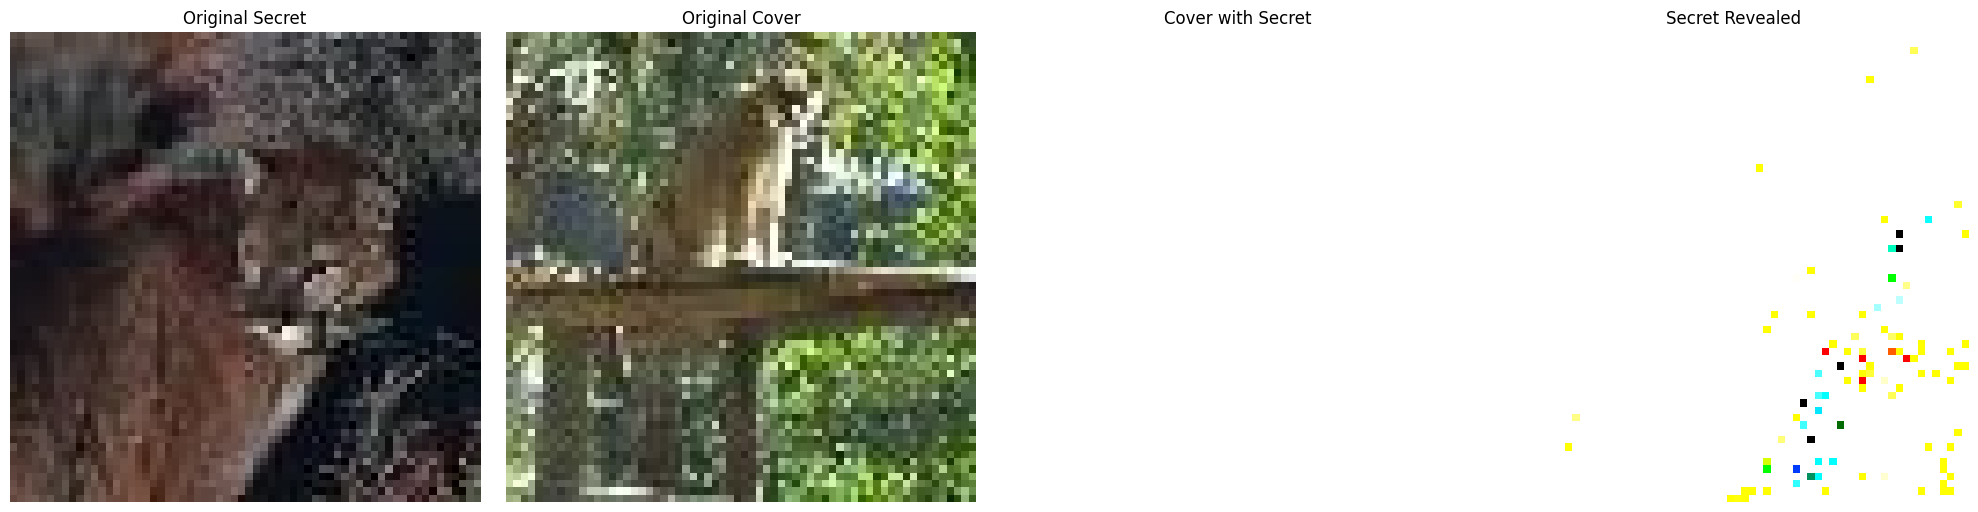

In [ ]:
import matplotlib.pyplot as plt

cover_img = holdout_cover[0].convert('RGB')
secret_img = holdout_secret[0].convert('RGB')

# Expand dims to add batch size

# Run Inference
prep_output = prep_network(np.array(secret_img))
hide_output = hide_network(np.array(cover_img), prep_output)
reveal_output = reveal_network(hide_output)

# Post-process (Scale back to 0-255)
hide_result = np.clip(hide_output.numpy.squeeze() * 255, 0, 255).astype(np.uint8)
reveal_result = np.clip(reveal_output.numpy().squeeze() * 255, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
images = [secret_img, cover_img, hide_result, reveal_result]
titles = ["Original Secret", "Original Cover", "Cover with Secret", "Secret Revealed"]

for i, ax in enumerate(axes):
    # Ensure images are displayed correctly even if they are in float format
    ax.imshow(images[i])
    ax.set_title(titles[i])
    ax.axis('off') # Hide the X/Y pixel coordinates for a cleaner look

plt.tight_layout()
plt.show()